# WhatsApp Chat - Topic Modelling using TF-IDF + LDA


| | NMF | LDA  |
|---|---|---|
| Full name | Non-negative Matrix Factorization | Latent Dirichlet Allocation |
| Type | Linear algebra (matrix factorization) | Probabilistic generative model |
| Topic representation | Hard weights | Probability distributions |
| Works best with | TF-IDF | Raw counts (but works with TF-IDF too) |
| Interpretability | Moderate | High - topics are probability distributions over words |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

## 2. Load & Preprocess WhatsApp Chat Data

In [2]:
df = pd.read_csv("mabel.txt", header=None, on_bad_lines='skip', encoding='utf8')
df = df.drop(0)
df.columns = ['Date', 'Chat']

Message  = df["Chat"].str.split("-", n=1, expand=True)
df["Time"] = Message[0]

Message1 = Message[1].str.split(":", n=1, expand=True)
df["Name"] = Message1[0]
df["Chat"] = Message1[1]

df = df[["Date", "Time", "Name", "Chat"]]
df.dropna(inplace=True)
df

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?
7,05/12/19,1:43 pm,AR❤,Yes Mam
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working
9,05/12/19,1:43 pm,AR❤,Yeah mam
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too


## 3. TF-IDF Vectorization

### Parameter choices explained

| Parameter | Value | Why |
|---|---|---|
| `max_df` | `0.95` | Ignore words appearing in more than 95% of messages (too common) |
| `min_df` | `2` | Ignore words appearing in fewer than 2 messages (too rare) |
| `stop_words` | `'english'` | Remove common English words like 'the', 'is', 'and' |
| `max_features` | `1000` | Keep only top 1000 words to reduce noise |

In [3]:
tfidf = TfidfVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words='english',
    max_features=1000
)

dtm = tfidf.fit_transform(df['Chat'])

print("Document-Term Matrix shape:", dtm.shape)
print(f"  {dtm.shape[0]} messages  x  {dtm.shape[1]} unique terms")

Document-Term Matrix shape: (50, 32)
  50 messages  x  32 unique terms


## 4. LDA - How it Works

LDA assumes every document is a **mixture of topics**, and every topic is a **mixture of words**.

```
Each Message
    └── is a mix of Topics  (e.g. 70% Topic 1, 20% Topic 3, 10% Topic 5)
            └── each Topic is a mix of Words  (e.g. Topic 1 = food, eat, lunch, dinner...)
```

LDA works backwards, given only the words, it tries to **reverse-engineer** the hidden topics.

> **Key difference from NMF:**  
> NMF gives weights. LDA gives **probabilities** - every topic assignment sums to 1.0 per document.

## 5. Train LDA Model

In [5]:
NUMBER_OF_TOPICS = 5   # explore more or fewer topics

lda_model = LatentDirichletAllocation(
    n_components=NUMBER_OF_TOPICS,
    random_state=42,
    max_iter=20,           # more iterations = better convergence
    learning_method='batch' # 'batch' is more accurate for small datasets
)

lda_model.fit(dtm)
print(f"Number of topics: {NUMBER_OF_TOPICS}")

Number of topics: 5


## 6. Display Top Words per Topic

Each topic is shown with its **top 10 most probable words** - these words help to understand what each topic is about.

In [7]:
feature_names = tfidf.get_feature_names_out()

for index, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:][::-1]]
    print(f"\nTopic {index + 1}:")
    print(" | ".join(top_words))


Topic 1:
ml | vignesh | details | send | office | just | hi | yes | need | number

Topic 2:
ok | need | yes | students | phone | office | number | ramisha | soon | meeting

Topic 3:
mam | yeah | finiliaze | kk | sure | abstract | read | think | project | ask

Topic 4:
tomorrow | project | meeting | church | know | just | office | mam | ask | soon

Topic 5:
abstracts | start | hi | ramisha | church | send | mam | ask | yes | details


### 6a. Topic-Word Probability Table

See the actual probability scores for top words in each topic.

In [8]:
for index, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words   = [feature_names[i] for i in top_indices]
    top_probs   = topic[top_indices] / topic.sum()   # normalise to probabilities

    topic_df = pd.DataFrame({'Word': top_words, 'Probability': top_probs.round(4)})
    print(f"\n--- Topic {index + 1} ---")
    print(topic_df.to_string(index=False))


--- Topic 1 ---
   Word  Probability
     ml       0.1156
vignesh       0.1139
details       0.0702
   send       0.0665
 office       0.0650
   just       0.0558
     hi       0.0517
    yes       0.0491
   need       0.0461
 number       0.0461

--- Topic 2 ---
    Word  Probability
      ok       0.2429
    need       0.0596
     yes       0.0541
students       0.0489
   phone       0.0489
  office       0.0460
  number       0.0460
 ramisha       0.0457
    soon       0.0449
 meeting       0.0443

--- Topic 3 ---
     Word  Probability
      mam       0.4363
     yeah       0.0598
finiliaze       0.0576
       kk       0.0527
     sure       0.0513
 abstract       0.0420
     read       0.0420
    think       0.0247
  project       0.0244
      ask       0.0217

--- Topic 4 ---
    Word  Probability
tomorrow       0.1764
 project       0.1019
 meeting       0.1015
  church       0.0785
    know       0.0522
    just       0.0521
  office       0.0172
     mam       0.0171
     ask

## 7. Assign Dominant Topic to Each Message

Every message gets assigned the topic it has the **highest probability** for.

In [9]:
# Transform: get topic probability distribution for each message
topic_results = lda_model.transform(dtm)

# Assign the dominant topic (highest probability)
df['Topic'] = topic_results.argmax(axis=1)
df['Topic_Label'] = df['Topic'].apply(lambda x: f"Topic {x + 1}")

# Also store the confidence (probability of the dominant topic)
df['Topic_Confidence'] = topic_results.max(axis=1).round(4)

df[['Name', 'Chat', 'Topic_Label', 'Topic_Confidence']]

,Name,Chat,Topic_Label,Topic_Confidence
1,Mabel Infoziant,Hi this is Mabel we just spoke,Topic 1,0.6599
2,Mabel Infoziant,What’s your full name,Topic 1,0.2000
3,AR❤,Ramisha Rani K,Topic 5,0.5983
4,Mabel Infoziant,Ok,Topic 2,0.6000
5,Mabel Infoziant,ramisharanik@gmail.com,Topic 1,0.2000
6,Mabel Infoziant,Your email Id?,Topic 1,0.2000
7,AR❤,Yes Mam,Topic 2,0.4687
8,Mabel Infoziant,I will send 2 abstracts for u to start working,Topic 5,0.7045
9,AR❤,Yeah mam,Topic 3,0.6572
10,Mabel Infoziant,Give me the list that u have too,Topic 1,0.2000


### 7a. Topic Distribution - How many messages per topic?

In [10]:
print(df['Topic_Label'].value_counts())

Topic_Label
Topic 3    16
Topic 1    14
Topic 2    10
Topic 5     6
Topic 4     4
Name: count, dtype: int64


## 8. Visualisations

### 8a. Message Count per Topic

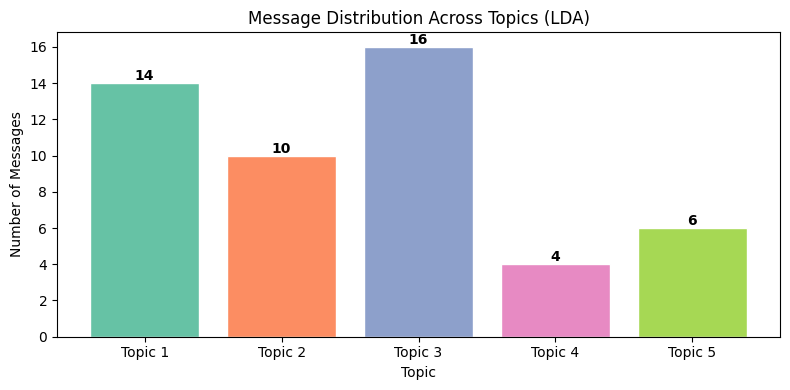

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
topic_counts = df['Topic_Label'].value_counts().sort_index()
colors = sns.color_palette('Set2', NUMBER_OF_TOPICS)

bars = ax.bar(topic_counts.index, topic_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, topic_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(val), ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Topic')
ax.set_ylabel('Number of Messages')
ax.set_title('Message Distribution Across Topics (LDA)')
plt.tight_layout()
plt.show()

### 8b. Topic Distribution per Person

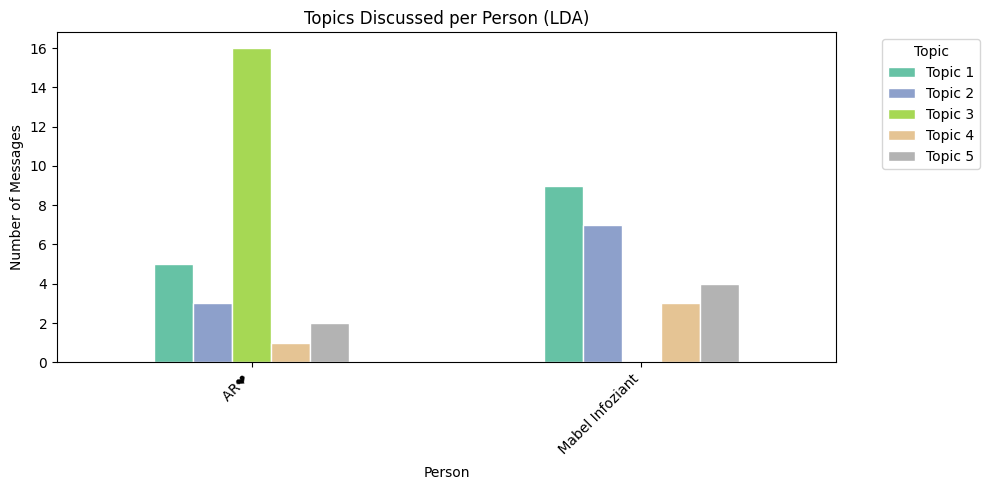

In [15]:
pivot = df.groupby(['Name', 'Topic_Label']).size().unstack(fill_value=0)

pivot.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Topics Discussed per Person (LDA)')
plt.xlabel('Person')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 8c. Topic Word Probability Bar Charts

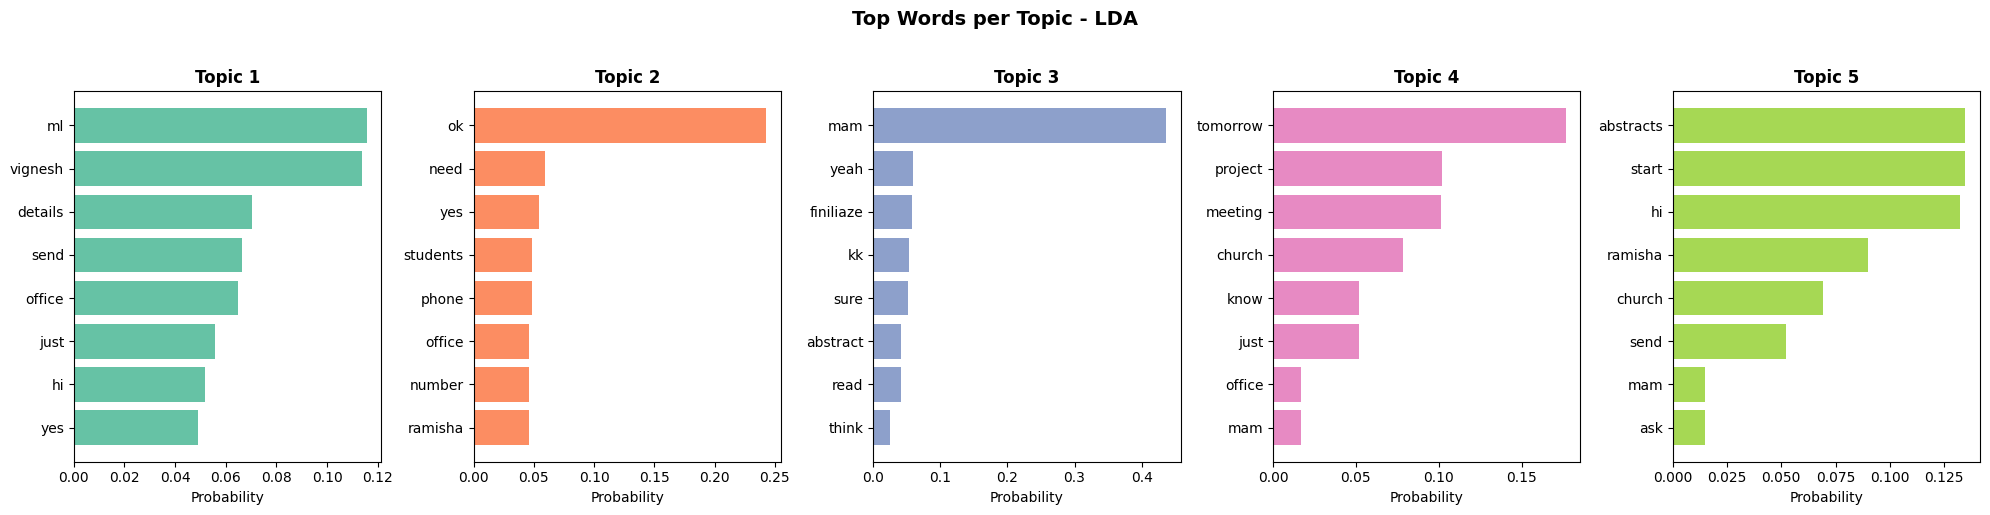

In [17]:
fig, axes = plt.subplots(1, NUMBER_OF_TOPICS, figsize=(4 * NUMBER_OF_TOPICS, 5))

for idx, (topic, ax) in enumerate(zip(lda_model.components_, axes)):
    top_indices = topic.argsort()[-8:][::-1]
    top_words   = [feature_names[i] for i in top_indices]
    top_probs   = topic[top_indices] / topic.sum()

    ax.barh(top_words[::-1], top_probs[::-1], color=sns.color_palette('Set2')[idx])
    ax.set_title(f'Topic {idx + 1}', fontweight='bold')
    ax.set_xlabel('Probability')

plt.suptitle('Top Words per Topic - LDA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Inspect Topic Probabilities for a Single Message

Unlike NMF, LDA gives a full **probability distribution** across all topics for each message.

In [18]:
MESSAGE_INDEX = 5   # inspect any message

print(f"Message: {df['Chat'].iloc[MESSAGE_INDEX]}")
print()
print("Topic probability distribution:")
for i, prob in enumerate(topic_results[MESSAGE_INDEX]):
    bar = '█' * int(prob * 40)
    print(f"  Topic {i+1}: {prob:.4f}  {bar}")

print(f"\nDominant Topic: Topic {topic_results[MESSAGE_INDEX].argmax() + 1}")

Message:  Your email Id?

Topic probability distribution:
  Topic 1: 0.2000  ████████
  Topic 2: 0.2000  ████████
  Topic 3: 0.2000  ████████
  Topic 4: 0.2000  ████████
  Topic 5: 0.2000  ████████

Dominant Topic: Topic 1


## 10. NMF vs LDA - Key Differences

<table style="text-align: left; margin-left: 0;">
  <thead>
    <tr><th>Feature</th><th>NMF (original)</th><th>LDA (this notebook)</th></tr>
  </thead>
  <tbody>
    <tr><td>Type</td><td>Matrix Factorization</td><td>Probabilistic Model</td></tr>
    <tr><td>Topic scores</td><td>Weights (any positive value)</td><td>Probabilities (sum to 1.0)</td></tr>
    <tr><td>Speed</td><td>Faster</td><td>Slower (iterative)</td></tr>
    <tr><td>Best vectorizer</td><td>TF-IDF</td><td>CountVectorizer (but TF-IDF works)</td></tr>
    <tr><td>Interpretability</td><td>Moderate</td><td>High</td></tr>
    <tr><td>Use case</td><td>Short texts, quick results</td><td>Long documents, formal topic modelling</td></tr>
  </tbody>
</table>

<br>

### Conclusion
> **LDA** is the gold standard for topic modelling - it gives proper probabilities and is widely used in research.  
> **NMF** is faster and works well for short texts like chat messages.  
> For WhatsApp chats (short messages), **NMF often gives cleaner topics**, but LDA gives richer probability information per message.